In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# ------------------------------------------------------------
# 1. Utility functions for multiparameter models
# ------------------------------------------------------------

def pack_model(vp, vs):
    """
    Pack multiparameter model into one vector.
    """
    return np.concatenate([vp.ravel(), vs.ravel()])


def unpack_model(m, n):
    """
    Unpack model vector into vp and vs.
    """
    vp = m[:n]
    vs = m[n:]
    return vp, vs


In [3]:
def dot_model(a, b):
    """
    Dot product in model space.
    For real FWI, this could include parameter weights.
    """
    return np.dot(a, b)


def norm_model(a):
    return np.sqrt(dot_model(a, a))

In [4]:
def apply_bounds(m, n, vp_min=1.5, vp_max=5.0, vs_min=0.5, vs_max=3.0):
    """
    Apply simple physical bounds to Vp and Vs.
    Units are arbitrary here.
    """
    vp, vs = unpack_model(m, n)

    vp = np.clip(vp, vp_min, vp_max)
    vs = np.clip(vs, vs_min, vs_max)

    # Optional physical condition: Vp > Vs
    vs = np.minimum(vs, 0.95 * vp)

    return pack_model(vp, vs)

In [5]:
# ------------------------------------------------------------
# 2. Toy nonlinear forward problem
# ------------------------------------------------------------

def build_smoothing_matrix(n, sigma=3.0):
    """
    Build a simple Gaussian-like smoothing matrix.
    This plays the role of wave propagation spreading sensitivity.
    """
    x = np.arange(n)
    A = np.zeros((n, n))

    for i in range(n):
        A[i, :] = np.exp(-0.5 * ((x - i) / sigma) ** 2)

    A /= A.sum(axis=1, keepdims=True)
    return A


In [6]:
def forward_model(m, n, A):
    """
    Toy nonlinear forward model.

    In real FWI, this would be your elastic wave-equation solver:
        d_cal = forward_elastic(vp, vs, rho, geometry)

    Here we make synthetic data sensitive to both Vp and Vs.
    """
    vp, vs = unpack_model(m, n)

    d1 = A @ vp
    d2 = A @ vs

    # Nonlinear coupling term, mimicking multiparameter coupling
    d3 = A @ (0.15 * vp * vs)

    # A mildly nonlinear term
    d4 = A @ (0.05 * vp**2)

    return np.concatenate([d1, d2, d3, d4])


In [7]:
def objective_and_residual(m, dobs, n, A):
    """
    Objective:
        J(m) = 0.5 ||dobs - f(m)||^2

    We use residual:
        r = dobs - dcal

    With this convention, a positive correlation with predicted data
    perturbation is consistent with Pica's expression.
    """
    dcal = forward_model(m, n, A)
    r = dobs - dcal
    J = 0.5 * np.dot(r, r)
    return J, r, dcal

In [8]:
# ------------------------------------------------------------
# 3. Gradient calculation for the toy problem
# ------------------------------------------------------------

def gradient(m, dobs, n, A):
    """
    Compute gradient of

        J = 0.5 ||dobs - f(m)||^2

    For the residual convention r = dobs - f(m),

        grad J = - J_f^T r

    where J_f is the Jacobian of the forward model.

    In real FWI, this would be your adjoint-state gradient.
    """
    vp, vs = unpack_model(m, n)

    J, r, dcal = objective_and_residual(m, dobs, n, A)

    r1 = r[0:n]
    r2 = r[n:2*n]
    r3 = r[2*n:3*n]
    r4 = r[3*n:4*n]

    # Contributions:
    # d1 = A vp
    # d2 = A vs
    # d3 = A (0.15 vp vs)
    # d4 = A (0.05 vp^2)

    At_r1 = A.T @ r1
    At_r2 = A.T @ r2
    At_r3 = A.T @ r3
    At_r4 = A.T @ r4

    # grad J = -J_f^T r
    g_vp = -At_r1
    g_vs = -At_r2

    g_vp += -(0.15 * vs) * At_r3
    g_vs += -(0.15 * vp) * At_r3

    g_vp += -(0.10 * vp) * At_r4

    g = pack_model(g_vp, g_vs)

    return J, g, r, dcal


In [9]:
# ------------------------------------------------------------
# 4. Optional gradient preprocessing
# ------------------------------------------------------------

def smooth_vector(x, radius=2):
    """
    Very simple moving-average smoothing.
    In real FWI, you might smooth gradients spatially.
    """
    if radius <= 0:
        return x.copy()

    kernel = np.ones(2 * radius + 1)
    kernel /= kernel.sum()

    return np.convolve(x, kernel, mode="same")


def preprocess_gradient(g, n, smooth_radius=2, scale_vp=1.0, scale_vs=1.0):
    """
    Apply simple smoothing and parameter scaling.

    In real elastic FWI, this is where you could apply:
    - illumination compensation,
    - water-layer mute,
    - model tapering,
    - Gaussian smoothing,
    - parameter balancing.
    """
    g_vp, g_vs = unpack_model(g, n)

    g_vp = smooth_vector(g_vp, radius=smooth_radius)
    g_vs = smooth_vector(g_vs, radius=smooth_radius)

    # Parameter scaling
    g_vp = scale_vp * g_vp
    g_vs = scale_vs * g_vs

    return pack_model(g_vp, g_vs)


In [10]:
# ------------------------------------------------------------
# 5. L-BFGS two-loop recursion
# ------------------------------------------------------------

def lbfgs_two_loop(g, memory):
    """
    Apply inverse Hessian approximation to gradient using L-BFGS.

    Returns:
        z = H g

    The descent direction is:
        p = -z

    memory is a list of dictionaries:
        {"s": s, "y": y, "rho": rho}
    """
    q = g.copy()
    alphas = []

    # First loop: newest to oldest
    for pair in reversed(memory):
        s = pair["s"]
        y = pair["y"]
        rho = pair["rho"]

        alpha = rho * dot_model(s, q)
        q = q - alpha * y
        alphas.append(alpha)

    # Initial inverse Hessian scaling
    if len(memory) > 0:
        s_last = memory[-1]["s"]
        y_last = memory[-1]["y"]

        sy = dot_model(s_last, y_last)
        yy = dot_model(y_last, y_last)

        if yy > 0.0:
            gamma = sy / yy
        else:
            gamma = 1.0
    else:
        gamma = 1.0

    z = gamma * q

    # Second loop: oldest to newest
    for pair, alpha in zip(memory, reversed(alphas)):
        s = pair["s"]
        y = pair["y"]
        rho = pair["rho"]

        beta = rho * dot_model(y, z)
        z = z + s * (alpha - beta)

    return z


In [11]:
def update_lbfgs_memory(memory, s, y, max_memory=5, curvature_eps=1e-10):
    """
    Store an L-BFGS pair if it satisfies the curvature condition.

        s^T y > 0

    In practice we use a small threshold.
    """
    sy = dot_model(s, y)

    if sy <= curvature_eps * norm_model(s) * norm_model(y):
        print("  Skipping L-BFGS pair: curvature condition failed.")
        return memory

    rho = 1.0 / sy

    memory.append({"s": s.copy(), "y": y.copy(), "rho": rho})

    if len(memory) > max_memory:
        memory.pop(0)

    return memory

In [13]:
# ------------------------------------------------------------
# 6. Pica finite-difference step length
# ------------------------------------------------------------

def choose_epsilon(m, p, n, fraction=0.01):
    """
    Choose epsilon so that the finite-difference perturbation is small.

    Roughly:
        max |epsilon p_parameter| <= fraction * max |m_parameter|

    This follows the spirit of Pica's appendix.
    """
    vp, vs = unpack_model(m, n)
    p_vp, p_vs = unpack_model(p, n)

    eps_list = []

    max_p_vp = np.max(np.abs(p_vp))
    max_p_vs = np.max(np.abs(p_vs))

    if max_p_vp > 0:
        eps_list.append(fraction * np.max(np.abs(vp)) / max_p_vp)

    if max_p_vs > 0:
        eps_list.append(fraction * np.max(np.abs(vs)) / max_p_vs)

    if len(eps_list) == 0:
        return 1.0

    return min(eps_list)


In [14]:
def pica_step_length(m, p, dobs, n, A, dcal, r):
    """
    Pica step length along direction p.

    We approximate:

        F p approx [f(m + epsilon p) - f(m)] / epsilon

    Pica formula:

        alpha = (Fp)^T r / (Fp)^T (Fp)

    If delta_d = f(m + epsilon p) - f(m), then

        Fp approx delta_d / epsilon

    so

        alpha = epsilon * (delta_d^T r) / (delta_d^T delta_d)
    """
    epsilon = choose_epsilon(m, p, n, fraction=0.01)

    m_eps = m + epsilon * p
    m_eps = apply_bounds(m_eps, n)

    d_eps = forward_model(m_eps, n, A)
    delta_d = d_eps - dcal

    denom = np.dot(delta_d, delta_d)

    if denom <= 0.0:
        return 0.0, epsilon

    alpha = epsilon * np.dot(delta_d, r) / denom

    return alpha, epsilon


In [15]:
# ------------------------------------------------------------
# 7. Main L-BFGS + Pica inversion loop
# ------------------------------------------------------------

def invert_lbfgs_pica(
    m0,
    dobs,
    n,
    A,
    niter=30,
    max_memory=5,
    max_backtracking=8,
    smooth_radius=2,
):
    """
    Main inversion loop.

    This is the part that most closely resembles the FWI pseudocode.
    """
    m = m0.copy()

    memory = []

    m_prev = None
    g_prev = None

    history = []

    for it in range(niter):

        print(f"\nIteration {it}")

        # ----------------------------------------------------
        # Forward + adjoint gradient
        # ----------------------------------------------------
        J, g_raw, r, dcal = gradient(m, dobs, n, A)

        # In real FWI, this could include illumination scaling.
        g = preprocess_gradient(
            g_raw,
            n,
            smooth_radius=smooth_radius,
            scale_vp=1.0,
            scale_vs=1.0,
        )

        print(f"  Misfit J = {J:.6e}")
        history.append(J)

        # ----------------------------------------------------
        # Form and store previous L-BFGS pair
        # ----------------------------------------------------
        if it > 0:
            s = m - m_prev
            y = g - g_prev
            memory = update_lbfgs_memory(
                memory,
                s,
                y,
                max_memory=max_memory,
                curvature_eps=1e-10,
            )

        # ----------------------------------------------------
        # Compute L-BFGS direction
        # ----------------------------------------------------
        if len(memory) == 0:
            p = -g
            print("  Direction: steepest descent")
        else:
            Hg = lbfgs_two_loop(g, memory)
            p = -Hg
            print(f"  Direction: L-BFGS with {len(memory)} stored pairs")

        # ----------------------------------------------------
        # Descent check
        # ----------------------------------------------------
        gtp = dot_model(g, p)

        if gtp >= 0.0:
            print("  Direction is not descent. Resetting memory.")
            memory.clear()
            p = -g
            gtp = dot_model(g, p)

        print(f"  g^T p = {gtp:.6e}")

        # ----------------------------------------------------
        # Pica step length along L-BFGS direction
        # ----------------------------------------------------
        alpha, epsilon = pica_step_length(m, p, dobs, n, A, dcal, r)

        print(f"  Pica epsilon = {epsilon:.6e}")
        print(f"  Pica alpha   = {alpha:.6e}")

        # If alpha is negative, the sign convention is inconsistent
        # or the direction is poor under the Pica linearization.
        if alpha <= 0.0:
            print("  Non-positive alpha from Pica. Using small fallback step.")
            alpha = 1e-3 / max(norm_model(p), 1e-12)

        # ----------------------------------------------------
        # Nonlinear safeguard / backtracking
        # ----------------------------------------------------
        accepted = False
        alpha_trial = alpha

        for bt in range(max_backtracking + 1):

            m_trial = m + alpha_trial * p
            m_trial = apply_bounds(m_trial, n)

            J_trial, r_trial, d_trial = objective_and_residual(
                m_trial, dobs, n, A
            )

            if J_trial < J:
                accepted = True
                print(
                    f"  Accepted alpha = {alpha_trial:.6e}, "
                    f"J_trial = {J_trial:.6e}, "
                    f"backtracking = {bt}"
                )
                break

            alpha_trial *= 0.5

        if not accepted:
            print("  No acceptable step found. Resetting memory and stopping.")
            memory.clear()
            break

        # ----------------------------------------------------
        # Save old model and gradient for next L-BFGS pair
        # ----------------------------------------------------
        m_prev = m.copy()
        g_prev = g.copy()

        # ----------------------------------------------------
        # Accept model
        # ----------------------------------------------------
        m = m_trial.copy()

    return m, history


Iteration 0
  Misfit J = 1.357225e+01
  Direction: steepest descent
  g^T p = -2.916421e+01
  Pica epsilon = 2.243242e-02
  Pica alpha   = 9.205049e-01
  Accepted alpha = 9.205049e-01, J_trial = 1.077575e-01, backtracking = 0

Iteration 1
  Misfit J = 1.077575e-01
  Direction: L-BFGS with 1 stored pairs
  g^T p = -1.466770e-01
  Pica epsilon = 3.911739e-01
  Pica alpha   = 1.191658e+00
  Accepted alpha = 1.191658e+00, J_trial = 1.974714e-02, backtracking = 0

Iteration 2
  Misfit J = 1.974714e-02
  Direction: L-BFGS with 2 stored pairs
  g^T p = -4.998956e-03
  Pica epsilon = 2.119171e+00
  Pica alpha   = 1.470711e+00
  Accepted alpha = 1.470711e+00, J_trial = 1.598172e-02, backtracking = 0

Iteration 3
  Misfit J = 1.598172e-02
  Direction: L-BFGS with 3 stored pairs
  g^T p = -5.793945e-04
  Pica epsilon = 5.550937e+00
  Pica alpha   = 1.339569e+00
  Accepted alpha = 1.339569e+00, J_trial = 1.557341e-02, backtracking = 0

Iteration 4
  Misfit J = 1.557341e-02
  Direction: L-BFGS wit

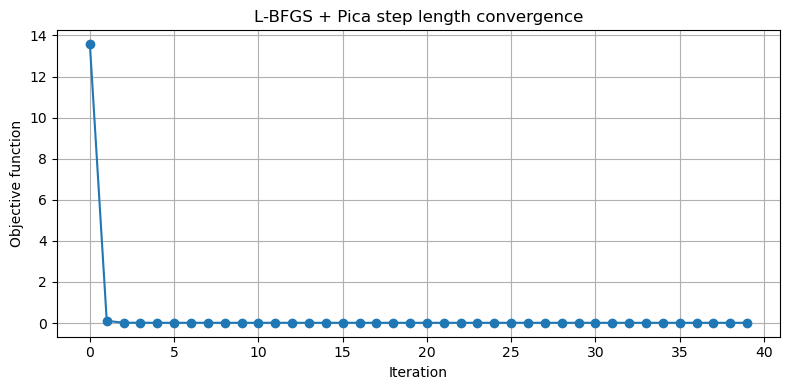

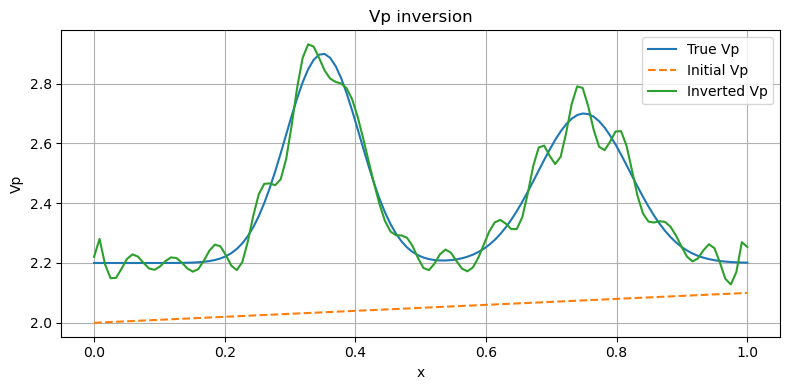

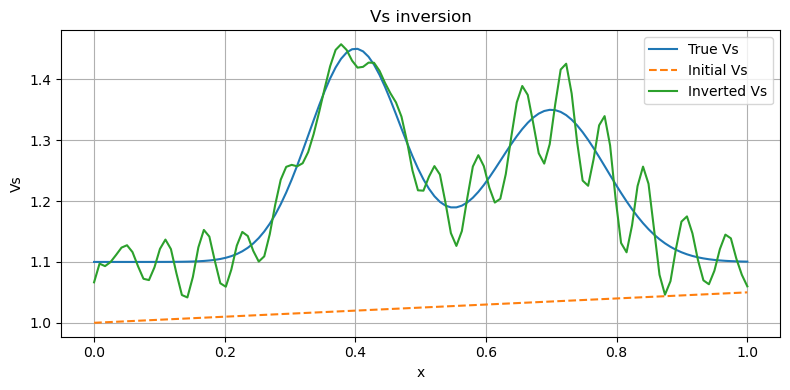

In [17]:
# ------------------------------------------------------------
# 8. Run a complete toy example
# ------------------------------------------------------------

if __name__ == "__main__":

    np.random.seed(7)

    n = 120
    x = np.linspace(0.0, 1.0, n)

    A = build_smoothing_matrix(n, sigma=3.0)

    # True elastic model
    vp_true = 2.2 + 0.7 * np.exp(-((x - 0.35) / 0.08) ** 2)
    vp_true += 0.5 * np.exp(-((x - 0.75) / 0.10) ** 2)

    vs_true = 1.1 + 0.35 * np.exp(-((x - 0.40) / 0.10) ** 2)
    vs_true += 0.25 * np.exp(-((x - 0.70) / 0.12) ** 2)

    m_true = pack_model(vp_true, vs_true)

    # Observed data
    dobs_clean = forward_model(m_true, n, A)

    noise_level = 0.01 * np.std(dobs_clean)
    dobs = dobs_clean + noise_level * np.random.randn(dobs_clean.size)

    # Initial model
    vp0 = 2.0 + 0.1 * x
    vs0 = 1.0 + 0.05 * x

    m0 = pack_model(vp0, vs0)

    # Run inversion
    m_inv, history = invert_lbfgs_pica(
        m0,
        dobs,
        n,
        A,
        niter=40,
        max_memory=7,
        max_backtracking=8,
        smooth_radius=1,
    )

    vp_inv, vs_inv = unpack_model(m_inv, n)

    # --------------------------------------------------------
    # Plot results
    # --------------------------------------------------------

    plt.figure(figsize=(8, 4))
    plt.plot(history, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function")
    plt.title("L-BFGS + Pica step length convergence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(x, vp_true, label="True Vp")
    plt.plot(x, vp0, "--", label="Initial Vp")
    plt.plot(x, vp_inv, label="Inverted Vp")
    plt.xlabel("x")
    plt.ylabel("Vp")
    plt.title("Vp inversion")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(x, vs_true, label="True Vs")
    plt.plot(x, vs0, "--", label="Initial Vs")
    plt.plot(x, vs_inv, label="Inverted Vs")
    plt.xlabel("x")
    plt.ylabel("Vs")
    plt.title("Vs inversion")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()